# Data Pre-Processing

In [ ]:
# Libraries
import pandas as pd # to work on the data set
import numpy as np # to perform any arthmetic operations  the data set
import matplotlib.pyplot as plt # to draw visualization
import scipy.stats as stats # to do statistics analysis


In [ ]:
# Load dataset
pd.set_option('display.max_columns', None) # to view all the columns in the data set
df = pd.read_csv('/cellphone_data.csv')
df.shape #to know the number of rows and columns available in the csv

(990, 22)

In [ ]:
df.head(10) #to show first 10 datas in the csv


,user_id,cellphone_id,rating,brand,model,operating system,internal memory,RAM,performance,main camera,selfie camera,battery size,screen size,weight,price(INR),release date,user_name,Region(City),Salary_in_INR,age,gender,occupation
0,0,30,1,Motorola,Moto G Play (2021),Android,32,3,1.42,13,5,5000,6.5,204,13888.65,14/01/2021,Ram,Delhi,570500,38,Female,Data analyst
1,0,5,3,Apple,iPhone XR,iOS,64,3,4.22,12,7,2942,6.1,194,20614.60,26/10/2018,Ram,Delhi,570500,38,Female,Data analyst
2,0,10,9,Samsung,Galaxy S22,Android,128,8,8.81,50,10,3700,6.1,167,46120.80,25/02/2022,Ram,Delhi,570500,38,Female,Data analyst
3,0,9,3,Samsung,Galaxy A53,Android,128,6,3.79,64,32,5000,6.5,189,27253.20,24/03/2022,Ram,Delhi,570500,38,Female,Data analyst
4,0,23,2,Vivo,X80 Pro,Android,256,8,9.81,50,32,4700,6.7,215,76169.20,29/04/2022,Ram,Delhi,570500,38,Female,Data analyst
5,0,8,2,Samsung,Galaxy A32,Android,64,4,2.20,48,13,5000,6.5,205,17382.65,22/01/2021,Ram,Delhi,570500,38,Female,Data analyst
6,0,22,1,Oppo,Find X5 Pro,Android,256,12,10.12,50,32,5000,6.7,218,86214.45,14/03/2022,Ram,Delhi,570500,38,Female,Data analyst
7,0,16,2,Google,Pixel 6a,Android,128,6,6.88,12,8,4410,6.1,178,39220.15,21/07/2021,Ram,Delhi,570500,38,Female,Data analyst
8,0,19,1,OnePlus,Nord 2T,Android,128,8,6.04,50,32,4500,6.4,190,33105.65,21/05/2022,Ram,Delhi,570500,38,Female,Data analyst
9,0,3,10,Apple,iPhone 13 Pro,iOS,256,6,7.94,12,12,3065,6.1,204,87262.65,24/09/2021,Ram,Delhi,570500,38,Female,Data analyst


In [ ]:
df.dtypes #to show the datatypes in the csv


,0
user_id,int64
cellphone_id,int64
rating,int64
brand,object
model,object
operating system,object
internal memory,int64
RAM,int64
performance,float64
main camera,int64


# Perform Other Data Pre-processing steps below such as checking data description, null values etc.

In [ ]:
#1) Check for missing values in each column

missing_values = df.isnull().sum()
# Check if there are any columns with missing values (i.e., any count > 0)
if (missing_values > 0).any():
    print("Columns with missing values and their counts:")
    display(missing_values[missing_values > 0]) # Display only those columns where the count of missing values is greater than 0
else:
    print("No missing values found in any column.")


No missing values found in any column.


In [ ]:
#2) Check for duplicate rows
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"There are {duplicate_rows} duplicate rows in the DataFrame.")
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate rows found in the DataFrame.")

No duplicate rows found in the DataFrame.


In [ ]:
#3) There is no unique id in the data set , so creating an auto-incremented column starting with 1

df = df.reset_index()
df = df.rename(columns={'index' : 'Record_id'})
df['Record_id'] = df['Record_id'] + 1
df.head(5)


,Record_id,user_id,cellphone_id,rating,brand,model,operating system,internal memory,RAM,performance,main camera,selfie camera,battery size,screen size,weight,price(INR),release date,user_name,Region(City),Salary_in_INR,age,gender,occupation
0,1,0,30,1,Motorola,Moto G Play (2021),Android,32,3,1.42,13,5,5000,6.5,204,13888.65,14/01/2021,Ram,Delhi,570500,38,Female,Data analyst
1,2,0,5,3,Apple,iPhone XR,iOS,64,3,4.22,12,7,2942,6.1,194,20614.60,26/10/2018,Ram,Delhi,570500,38,Female,Data analyst
2,3,0,10,9,Samsung,Galaxy S22,Android,128,8,8.81,50,10,3700,6.1,167,46120.80,25/02/2022,Ram,Delhi,570500,38,Female,Data analyst
3,4,0,9,3,Samsung,Galaxy A53,Android,128,6,3.79,64,32,5000,6.5,189,27253.20,24/03/2022,Ram,Delhi,570500,38,Female,Data analyst
4,5,0,23,2,Vivo,X80 Pro,Android,256,8,9.81,50,32,4700,6.7,215,76169.20,29/04/2022,Ram,Delhi,570500,38,Female,Data analyst


In [ ]:
#4) the data type of release_date seems to be an object , can convert the same to date format
df['release date'] = pd.to_datetime(df['release date'], format='mixed',dayfirst=True)
display(df['release date'])

,release date
0,2021-01-14
1,2018-10-26
2,2022-02-25
3,2022-03-24
4,2022-04-29
...,...
985,2021-10-14
986,2021-10-28
987,2022-04-29
988,2022-07-27


## Split the variables in the dataset into numerical and categorical types.

In [ ]:
#Finding out the numerical and categorical fields in the data set
#To select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical Columns: ",numerical_columns)

# To select categorical (object) columns
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns: ",categorical_columns)

Numerical Columns:  ['Record_id', 'user_id', 'cellphone_id', 'rating', 'internal memory', 'RAM', 'performance', 'main camera', 'selfie camera', 'battery size', 'screen size', 'weight', 'price(INR)', 'Salary_in_INR', 'age']
Categorical Columns:  ['brand', 'model', 'operating system', 'user_name', 'Region(City)', 'gender', 'occupation']


## Create boxplots for all numerical variables to check for outliers.

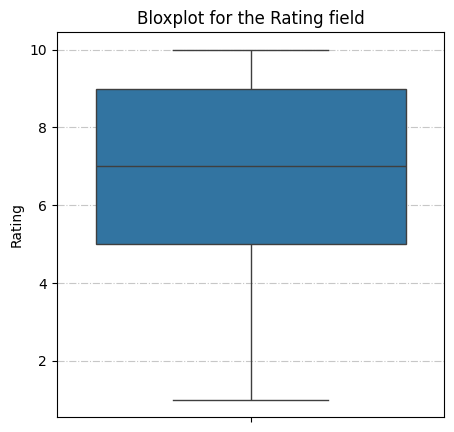

In [ ]:
# Creating boxplot for one numerical value --> Rating

import seaborn as sns
import matplotlib.pyplot as plt

# boxplot for rating
plt.figure(figsize = (5,5))
sns.boxplot(y=df['rating'])
plt.title('Bloxplot for the Rating field')
plt.ylabel('Rating')
plt.grid(axis = 'y',linestyle='-.',alpha = 0.7)
plt.show()
# from the plot , we could not see any outliners , the median lies in between the IQR(Q1-Q3) around 7.
# the Q1 is approximately 5 nd Q3 is around 9 so majority of the data lies between 5 To 9 .
#The plot is slightly left skewed because the lower tail is higher than the upper tail .


The numercial coulmns are : ['internal memory', 'RAM', 'performance', 'main camera', 'selfie camera', 'battery size', 'screen size', 'weight', 'price(INR)', 'Salary_in_INR', 'age']
Generating Box Plots for Numerical Columns:


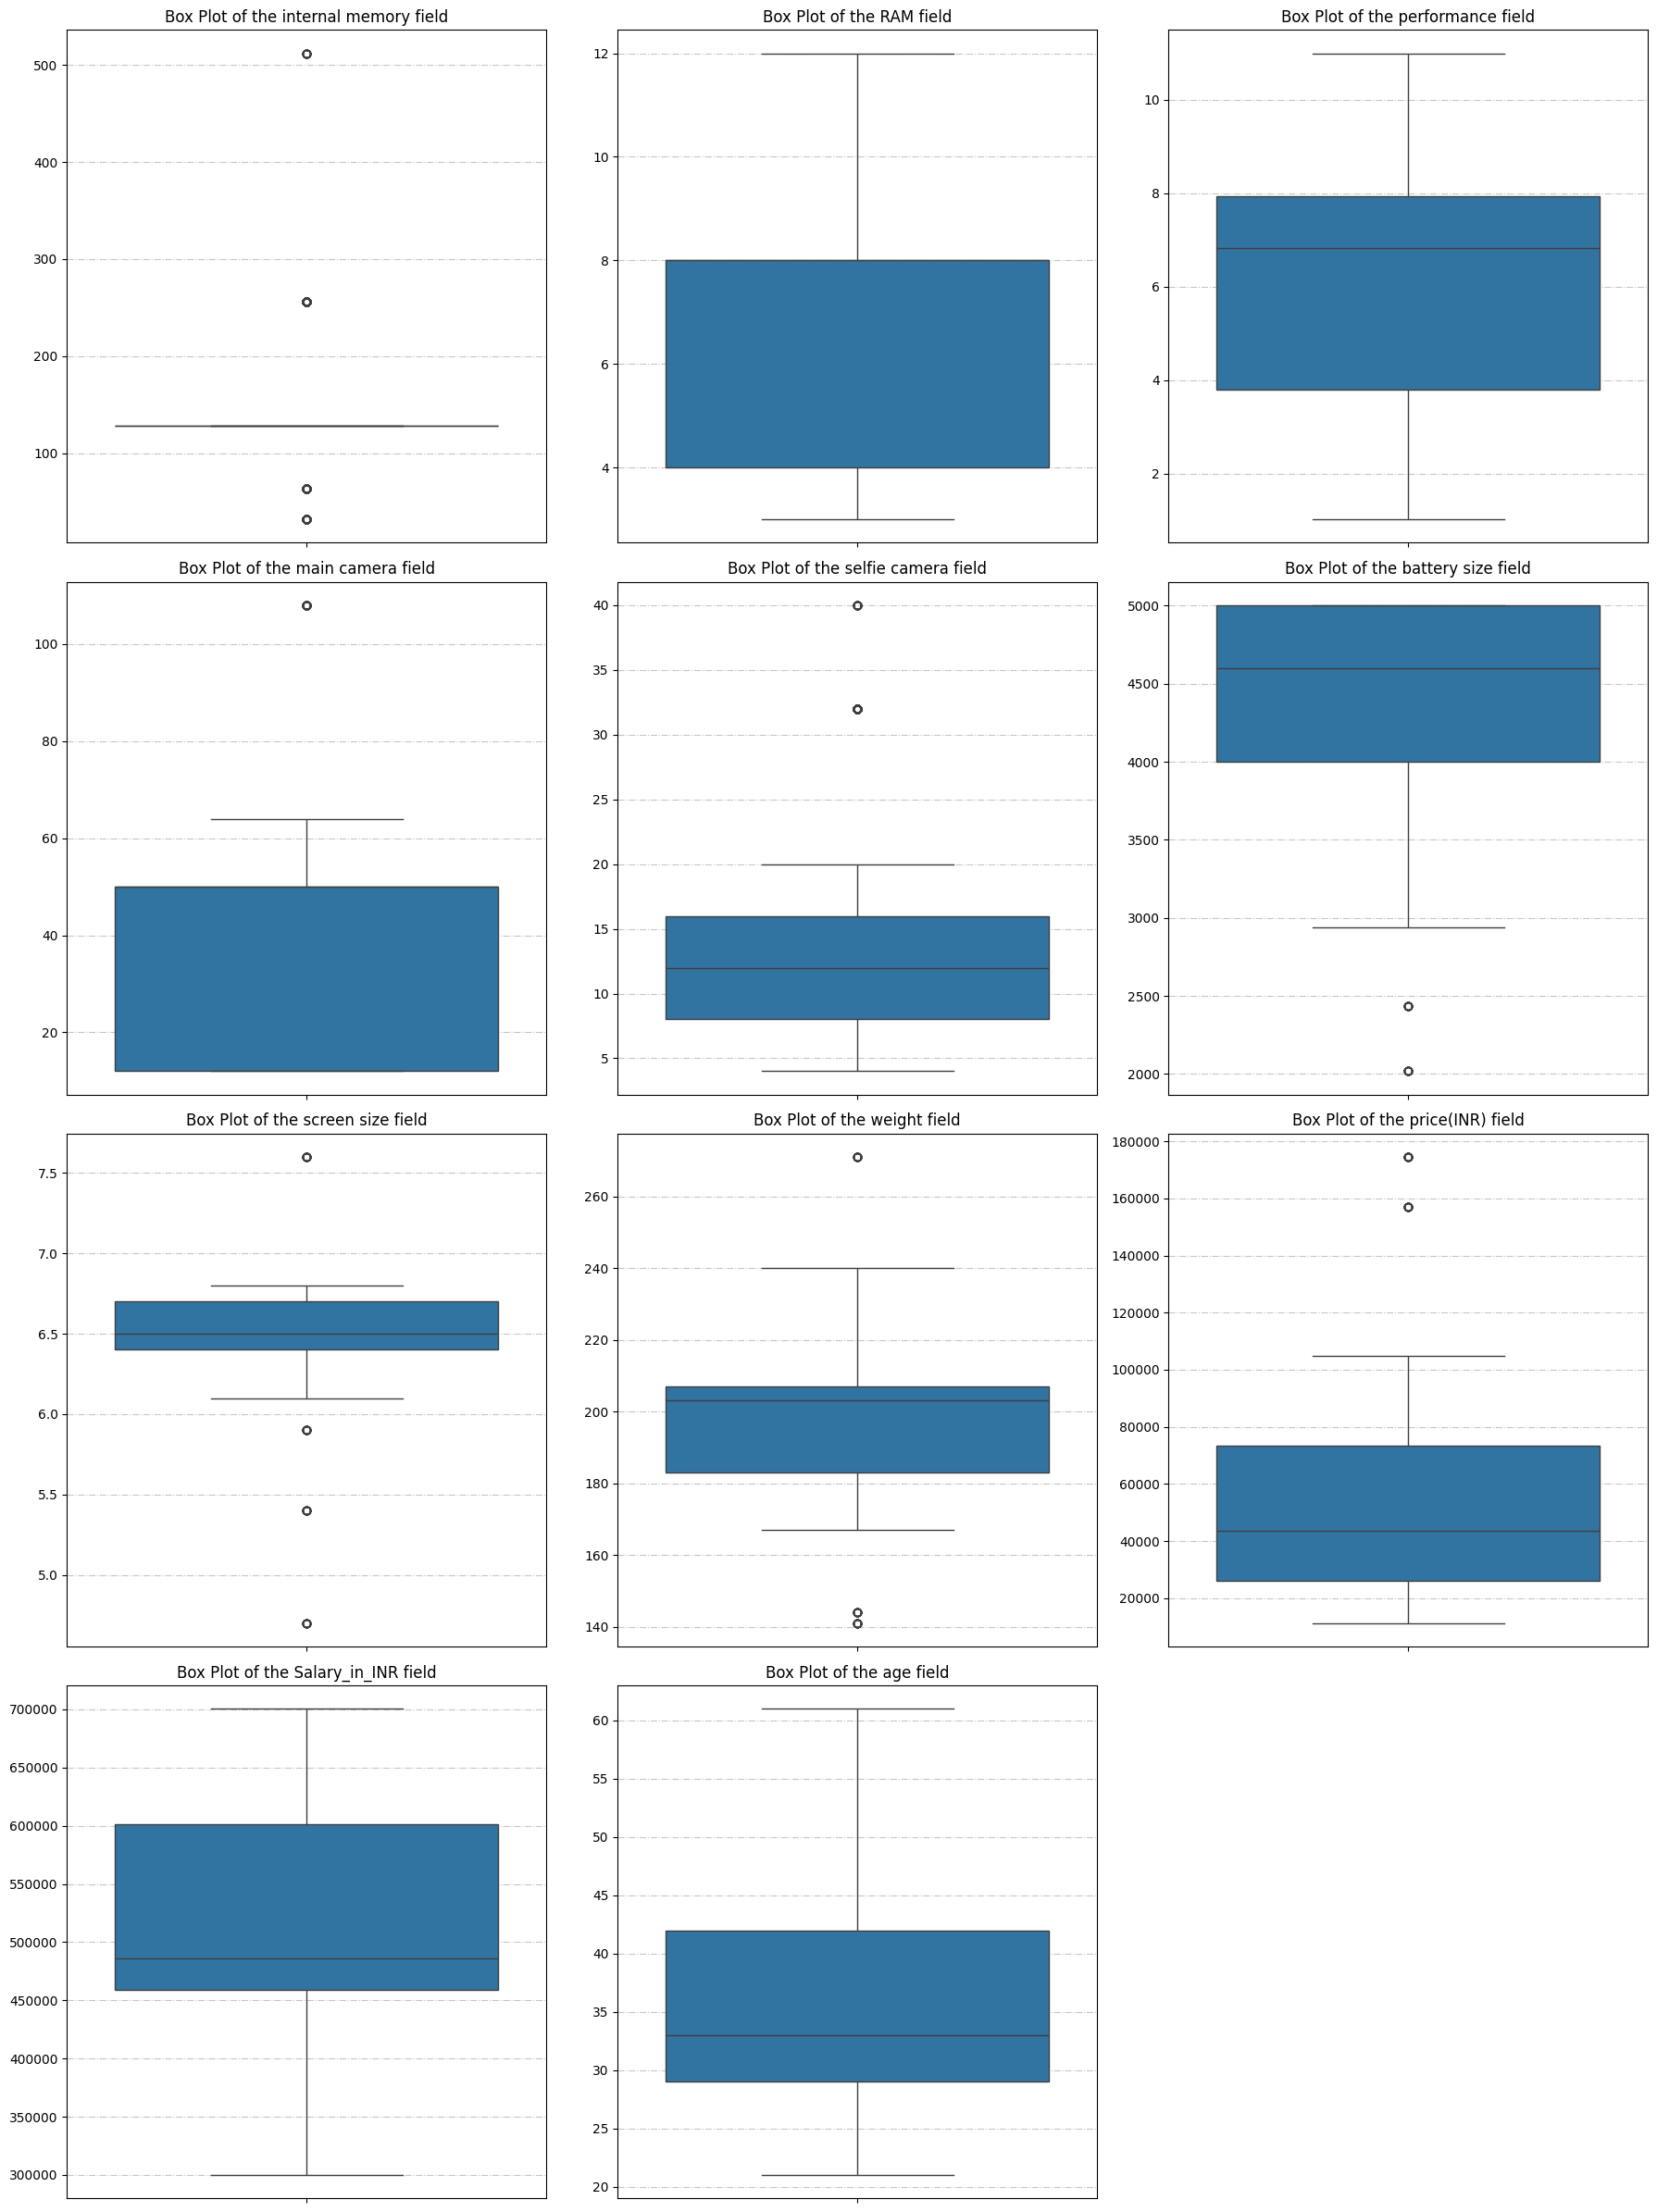

In [ ]:
# creating boxplots
import seaborn as sns
import matplotlib.pyplot as plt

# Get numerical columns from the previously identified list
# Exclude identifiers that are not typically analyzed with box plots for distribution
new_numerical_column = [col for col in numerical_columns if col not in ['Record_id', 'user_id', 'cellphone_id', 'rating']]

print("The numercial coulmns are : " + str(new_numerical_column) + "\n" + "Generating Box Plots for Numerical Columns:")

#print("Generating Box Plots for Numerical Columns:")

# Determine the number of rows and columns for the subplot grid
num_plots = len(new_numerical_column)
num_cols = 3  # You can adjust this for more or fewer columns per row
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 6, num_rows * 6)) # Adjust figure size dynamically

for i, col in enumerate(new_numerical_column):
    plt.subplot(num_rows, num_cols, i + 1) # Create subplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of the {col} field')
    plt.ylabel('') # Remove y-axis label to avoid clutter if multiple plots
    plt.grid(axis='y', linestyle='-.', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Inferences :

1)performance:
Median≈6.5-6.9) indicating most phones have moderate to strong performance.
IQR≈(4–7.9) indicating wide spread, indicating that performance varies across models.
Range≈((1–11) indicating the dataset includes  mid-range and budget phones.
Whiskers fairly equal showing distribution is almost symmetric.
Conclusion:
Performance levels are generally mid-to-high with some low-end and some high-end performers, showing a balanced distribution across segments.

2)selfie camera:
Median = 12.5 MP
Range≈(7.5–16 MP) indicating both low-quality and high-end selfie cameras exist.
Moderate IQR → Most phones fall between mid-range selfie cameras.
Some upper outliers like (32.5-40) ,showing  premium cell phones.
Conclusion:
Selfie cameras in this dataset are centered around 12.5 MP, with premium phones pushing the upper range and creating right-skewness.

3)main camera:
Median = __ indicsting many phones have strong camera hardware.
Q1 = 12, Q3 = 50 indicating most phones comes between budget and mid/high-level camera.
High-end outliers (above 100) indicating premium phones and very low whisker indicating very few phones have less main camera specifications compared to other models.
Conclusion:
Distribution is right-skewed, dominated by mid/high-end camera setups with a few with very high quality.

4)RAM:
Median =6 ,indicating most phones are mid/high-range.
Range: 4–8 ,indicating huge variation (from basic to advanced).
Moderate size IQR , indicating RAM capacity is highly spread out.
Upper whisker length is higher compared to lower indicating gaming or ultra-premium phones.
Conclusion:
RAM distribution is wide and right-skewed, showing clear separation between budget phones (4–8) and high-end phones (12).

5)internal memory:
Several Outliners are there clustered  mainly below 100~(64),250 and above 500
Large range but not continuous,typical with smartphone storage tiers.
Boxplot likely shows multiple clusters rather than smooth spread.
Conclusion:
Internal memory follows market storage tiers,  around 100-200 GB being most common. Upper values (250–510 GB) act as outliers.

6)battery size:
IQR: 4000–5000
Very small IQR, indicating extremely consistent across phones.
No outliers , and upper whisker is barely seen indicating an standardized capacity is there across all cel phones.
Conclusion:
Battery capacity shows almost no variation, reflecting modern uniform standards in smartphone design.

7)screen size:
IQR between 6.4–6.8 inches , very less range showing narrow distribution
no visible outliers , the lower whisker is visibl higher than the upper whisker .
Conclusion:
Screen size is highly standardized; modern smartphones almost all fall in the 6–7 inch range.

8)weight:
Median ≈ 205
IQR: 185–212 g
Few upper outliers above 260 , indicating bulky/battery in heavy cell phones
Moderate distribtion is there
Conclusion:
Most phones weigh around 185–210, with heavier premium models forming the high-end tail.

9)price(INR):
IQR: ₹25k -₹75 , indicating kind of mid range to slightly hig price and prices vary widely .
Median around ₹43k ,indicating mid-range pricing.
Strong right skew due to premium phone price range.
Conclusion:
Price is highly right-skewed; a few expensive flagship phones pull the distribution upward. Most phones remain mid-range.

10)age:
Median = 33 years
IQR: 29 - 42 years, indicating a wide range of regular users
Fairly symmetric distribution
Conclusion:
Majority of users are young/middle-aged adults, showing general smartphone adoption patterns.

11)Salary_in_INR
Range: 4.6 lks -6 lks and median nearly 4.8 lks
Indicating Salary distribution is somewhat narrow
Few outliers in higher income
Conclusion:
User income levels are relatively clustered, with slight right skew driven by higher-income users.

## Generate a heatmap for all numerical variables to examine their correlations.

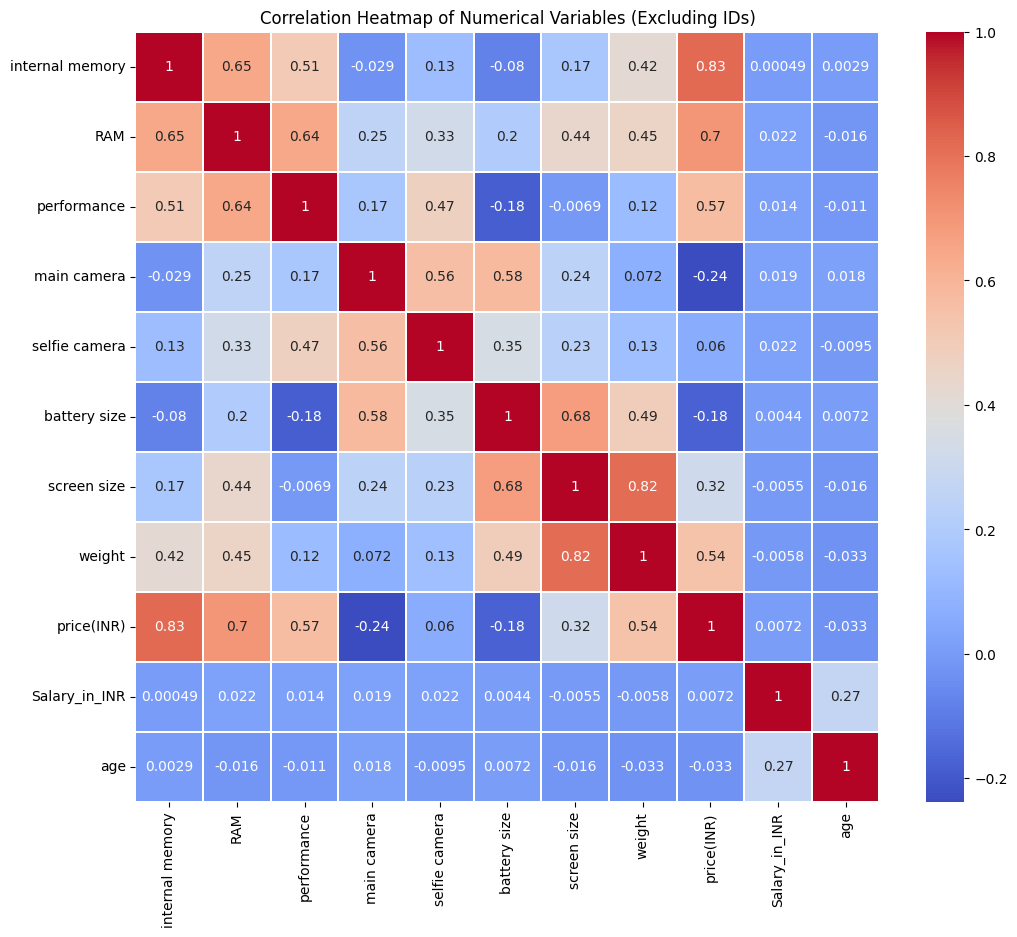

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter numerical columns to exclude identifiers
# Reusing numerical_cols_for_boxplot which already excludes 'Record_id', 'user_id', 'cellphone_id'
numerical_cols_for_heatmap = new_numerical_column

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols_for_heatmap].corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2g", linewidths=.3)
plt.title('Correlation Heatmap of Numerical Variables (Excluding IDs)')
plt.show()

Observations:
Strong Positive Correlations (closer to (1-0.6), indicated by darker red shades):
All numerical field's correlation with the same will be a strong positive , That is why we are getting a diagonal red square with value as 1
For price(INR) with :
1)internal memory(0.83)
2)RAM(0.70)
3)performance(0.57)
This indicates that as price for the cell phone increases , more will be its performance ,higher internal memory, more RAM
For Weight with screen size(0.82) , indicates as weight increase the screen size increas
For performance with RAM size(0.64) and  For RAM with internal memory(0.67), high performance cell phones will have high range of RAM which in turn will increase the internal memory .

Moderate and Positve Correlations(closer to (0.6-0.4), indicated by light red shades):
For price(INR) with weight (0.54)
For weight with battery size(0.49)
For screen size with battery size(0.68)
For selfie camers with
1)main camera(0.56)
2)performance(0.47)
For main camera with battery size(0.58)
For performance with internal memory(0.51)
this all tells that more expensive phones generally come with higher internal memory, more RAM, better performance, better cameras, larger screens,
and are heavier.

Weak or No Correlation (close to 0(from 0.4-0), white/light shades):
Salary_in_INR and age: These two variables show very weak correlations with most other technical specifications of the cellphone. This indicates that a user's salary or age does not strongly dictate the specific hardware features (like RAM, internal memory, camera, etc.) they purchase. Their decisions might be influenced by other factors not captured here or are spread across various phone types.
There's almost no correlation between internal memory and main camera (-0.029).

Negative Correlations (closer to -1, indicated by darker blue shades):
There are very few significant negative correlations. One notable one is price(INR) with main camera (-0.24).
It might imply that very high-priced phones aren't necessarily leading the pack in raw main camera MP , this correlation need more focusing since all other factors goes up as price increases .

The heatmap clearly shows that technical specifications like internal memory, RAM, performance, main camera, selfie camera, screen size and weight
are generally positively correlated with each other and, mostly, with price(INR).
This is expected, as higher featured phones tend to be more expensive.
Salary_in_INR and age have very little linear correlation with phone specifications, suggesting diverse purchasing behaviors across different income and age groups relative to hardware.
The slight negative correlation between price(INR) and main camera is an interesting point that might need a deep level of investigation.

## Create count plots for all categorical variables to visualize their distributions.

Generating Count Plots for Categorical Columns:


<Figure size 1800x1800 with 0 Axes>

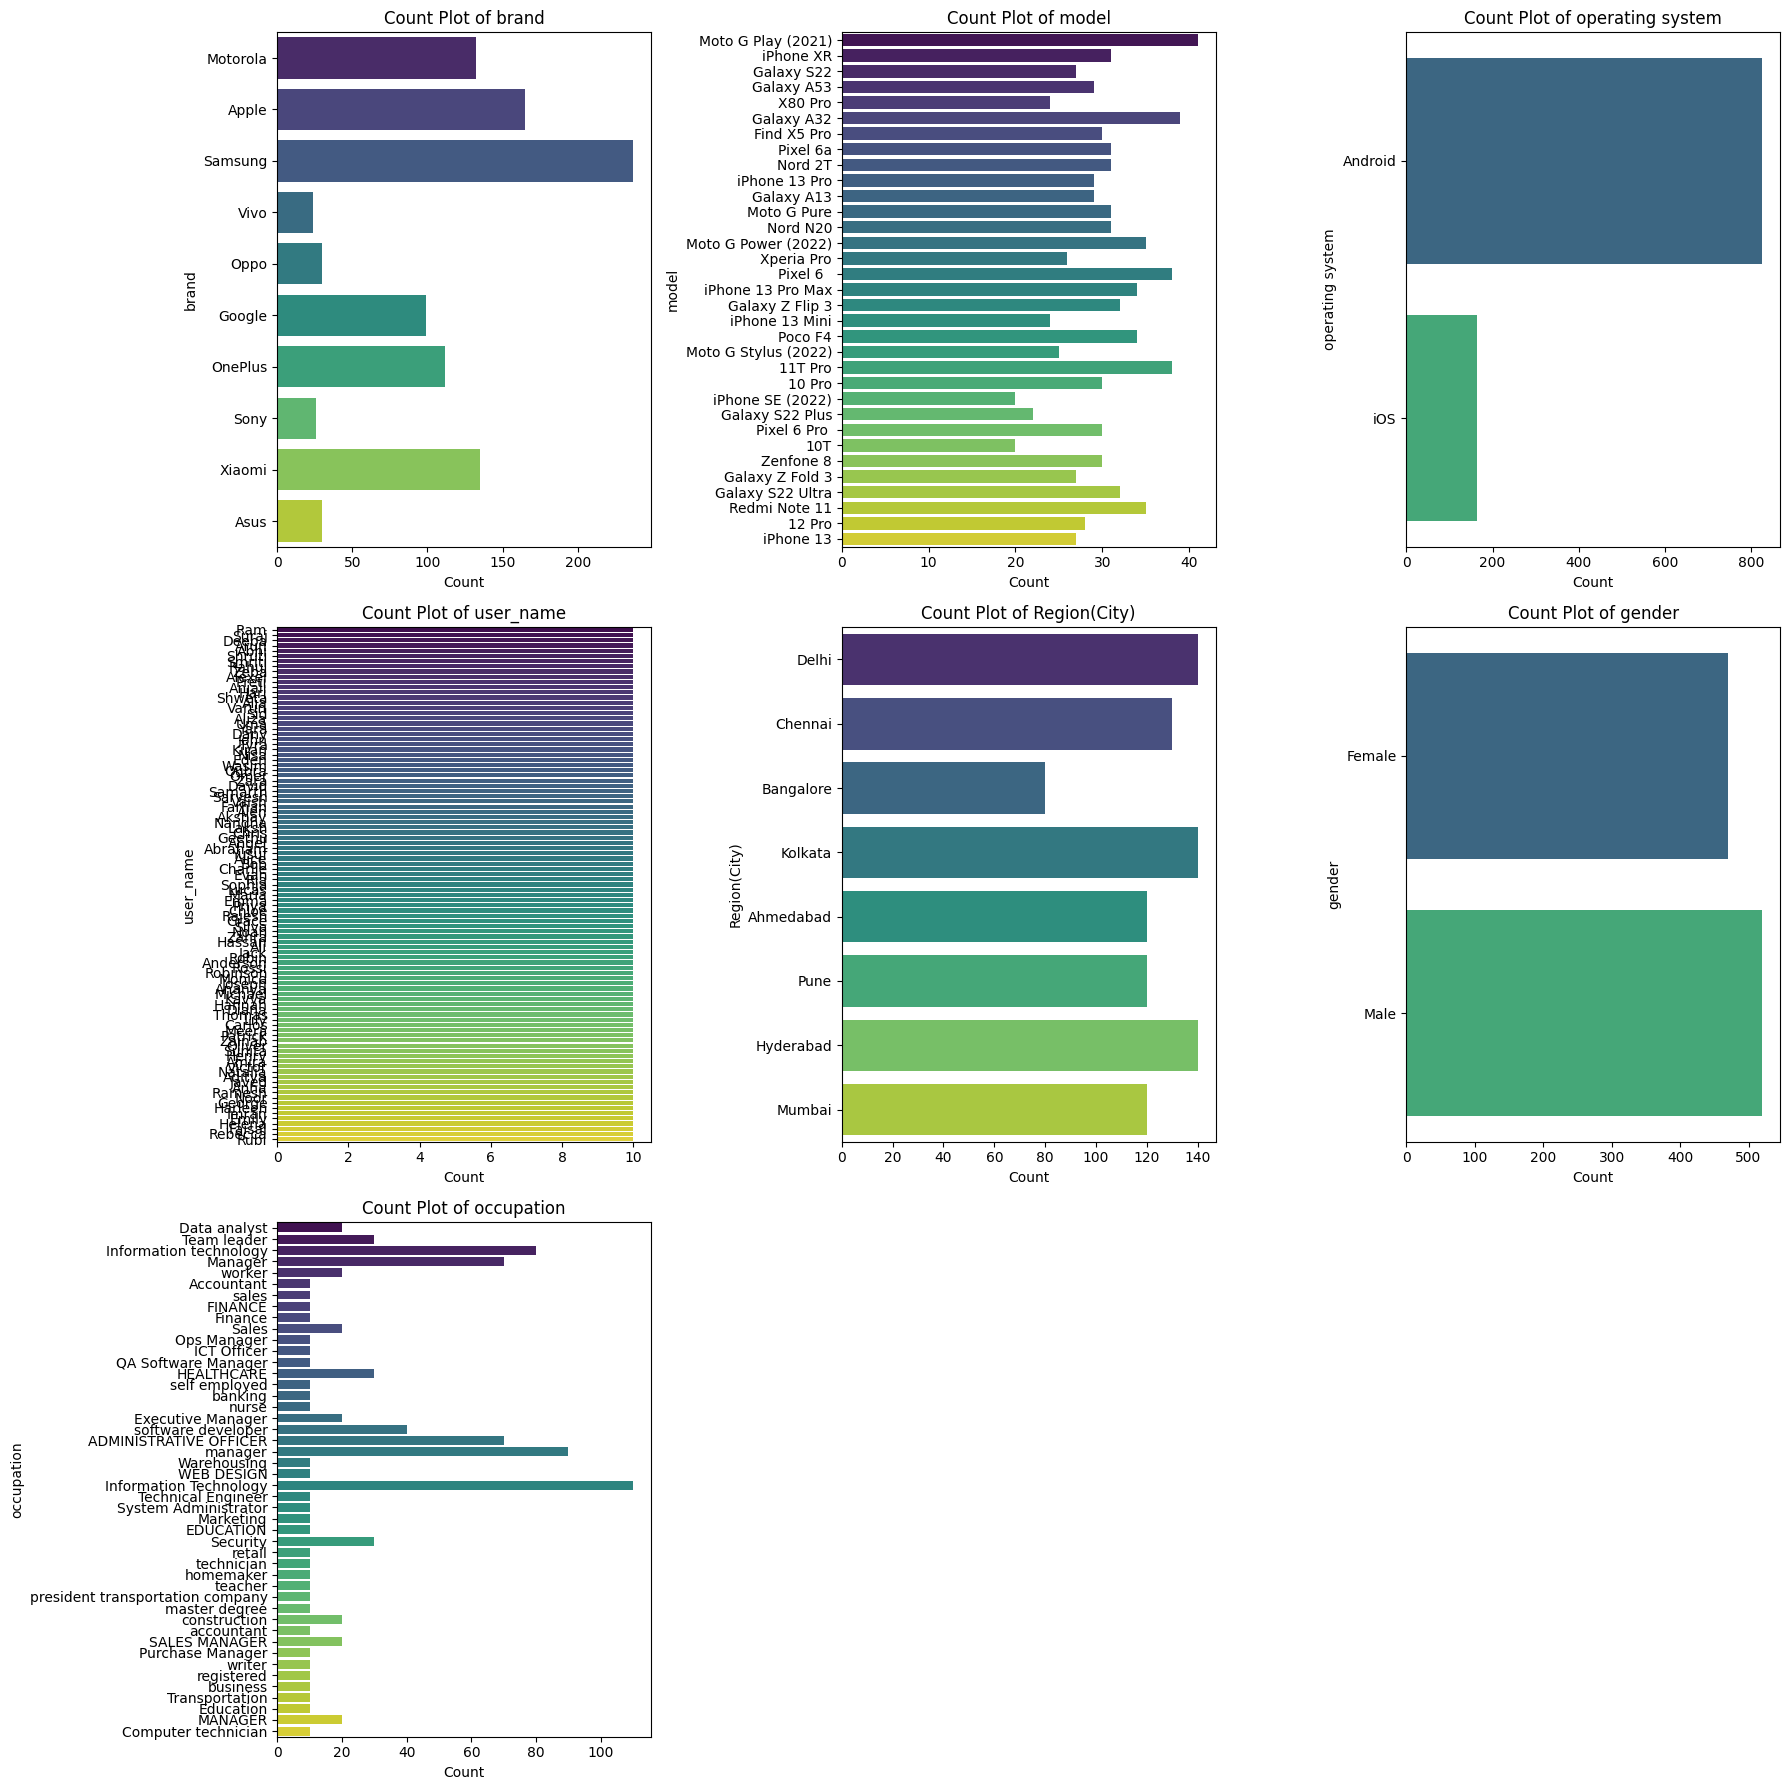

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of categorical columns (already defined in the notebook state)

print("Generating Count Plots for Categorical Columns:")

# Determine the number of rows and columns for the subplot grid
num_cat_plots = len(categorical_columns)
num_cat_cols = 3  # You can adjust this for more or fewer columns per row
num_cat_rows = (num_cat_plots + num_cat_cols - 1) // num_cat_cols # Calculate rows needed

plt.figure(figsize=(num_cat_cols * 6, num_cat_rows * 6)) # Adjust figure size dynamically

# Flatten the axes array for easy iteration
fig, axes = plt.subplots(num_cat_rows, num_cat_cols, figsize=(num_cat_cols * 6, num_cat_rows * 6))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    if i < len(axes): # Ensure we don't go out of bounds for axes
        sns.countplot(y=df[col], ax=axes[i], palette='viridis', hue=df[col], legend=False)
        axes[i].set_title(f'Count Plot of {col}')
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel(col) # Set y-label to column name

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Inferences from Count Plots
brand: Samsung appears to be a strong component followed by Apple and Xiamoi , while Asus, sony are less popular cell phones

model: There are many unique models for brand listed above and it is that certain popular models from top brands (like various Samsung Galaxy or Xiaomi Redmi models) have higher counts.
The various model type may be due to various customer preferences .

operating system: There are only two components and we could see users are more interested in Android than iOS .

user_name: There is a wide range of users and for further study the names of users are not much needed .

Region(City):Cities like Delhi, Kolkata, Hyderabad, and Chennai have a higher number of entries compared to others like Bangalore, Mumbai and Pune, which
have slightly fewer but still substantial counts.

gender:The distribution between male and female is relatively balanced, with slightly more male entries than female entries.

occupation:The 'occupation' plot reveals a wide variety of occupations.'Information Technology' and 'software developers' and 'managers'  are among the most frequent, but there are many other occupations with low counts, indicating high diversity.
it seems that techies seems to use more compare to other occupation .Also there seems to be spellin mistake and data redudancy in the field , like Information Technology and Information technology .

## Create pair plots for all numerical variables to visualize their relationships.

Generating Pair Plots for Numerical Variables (Excluding IDs).


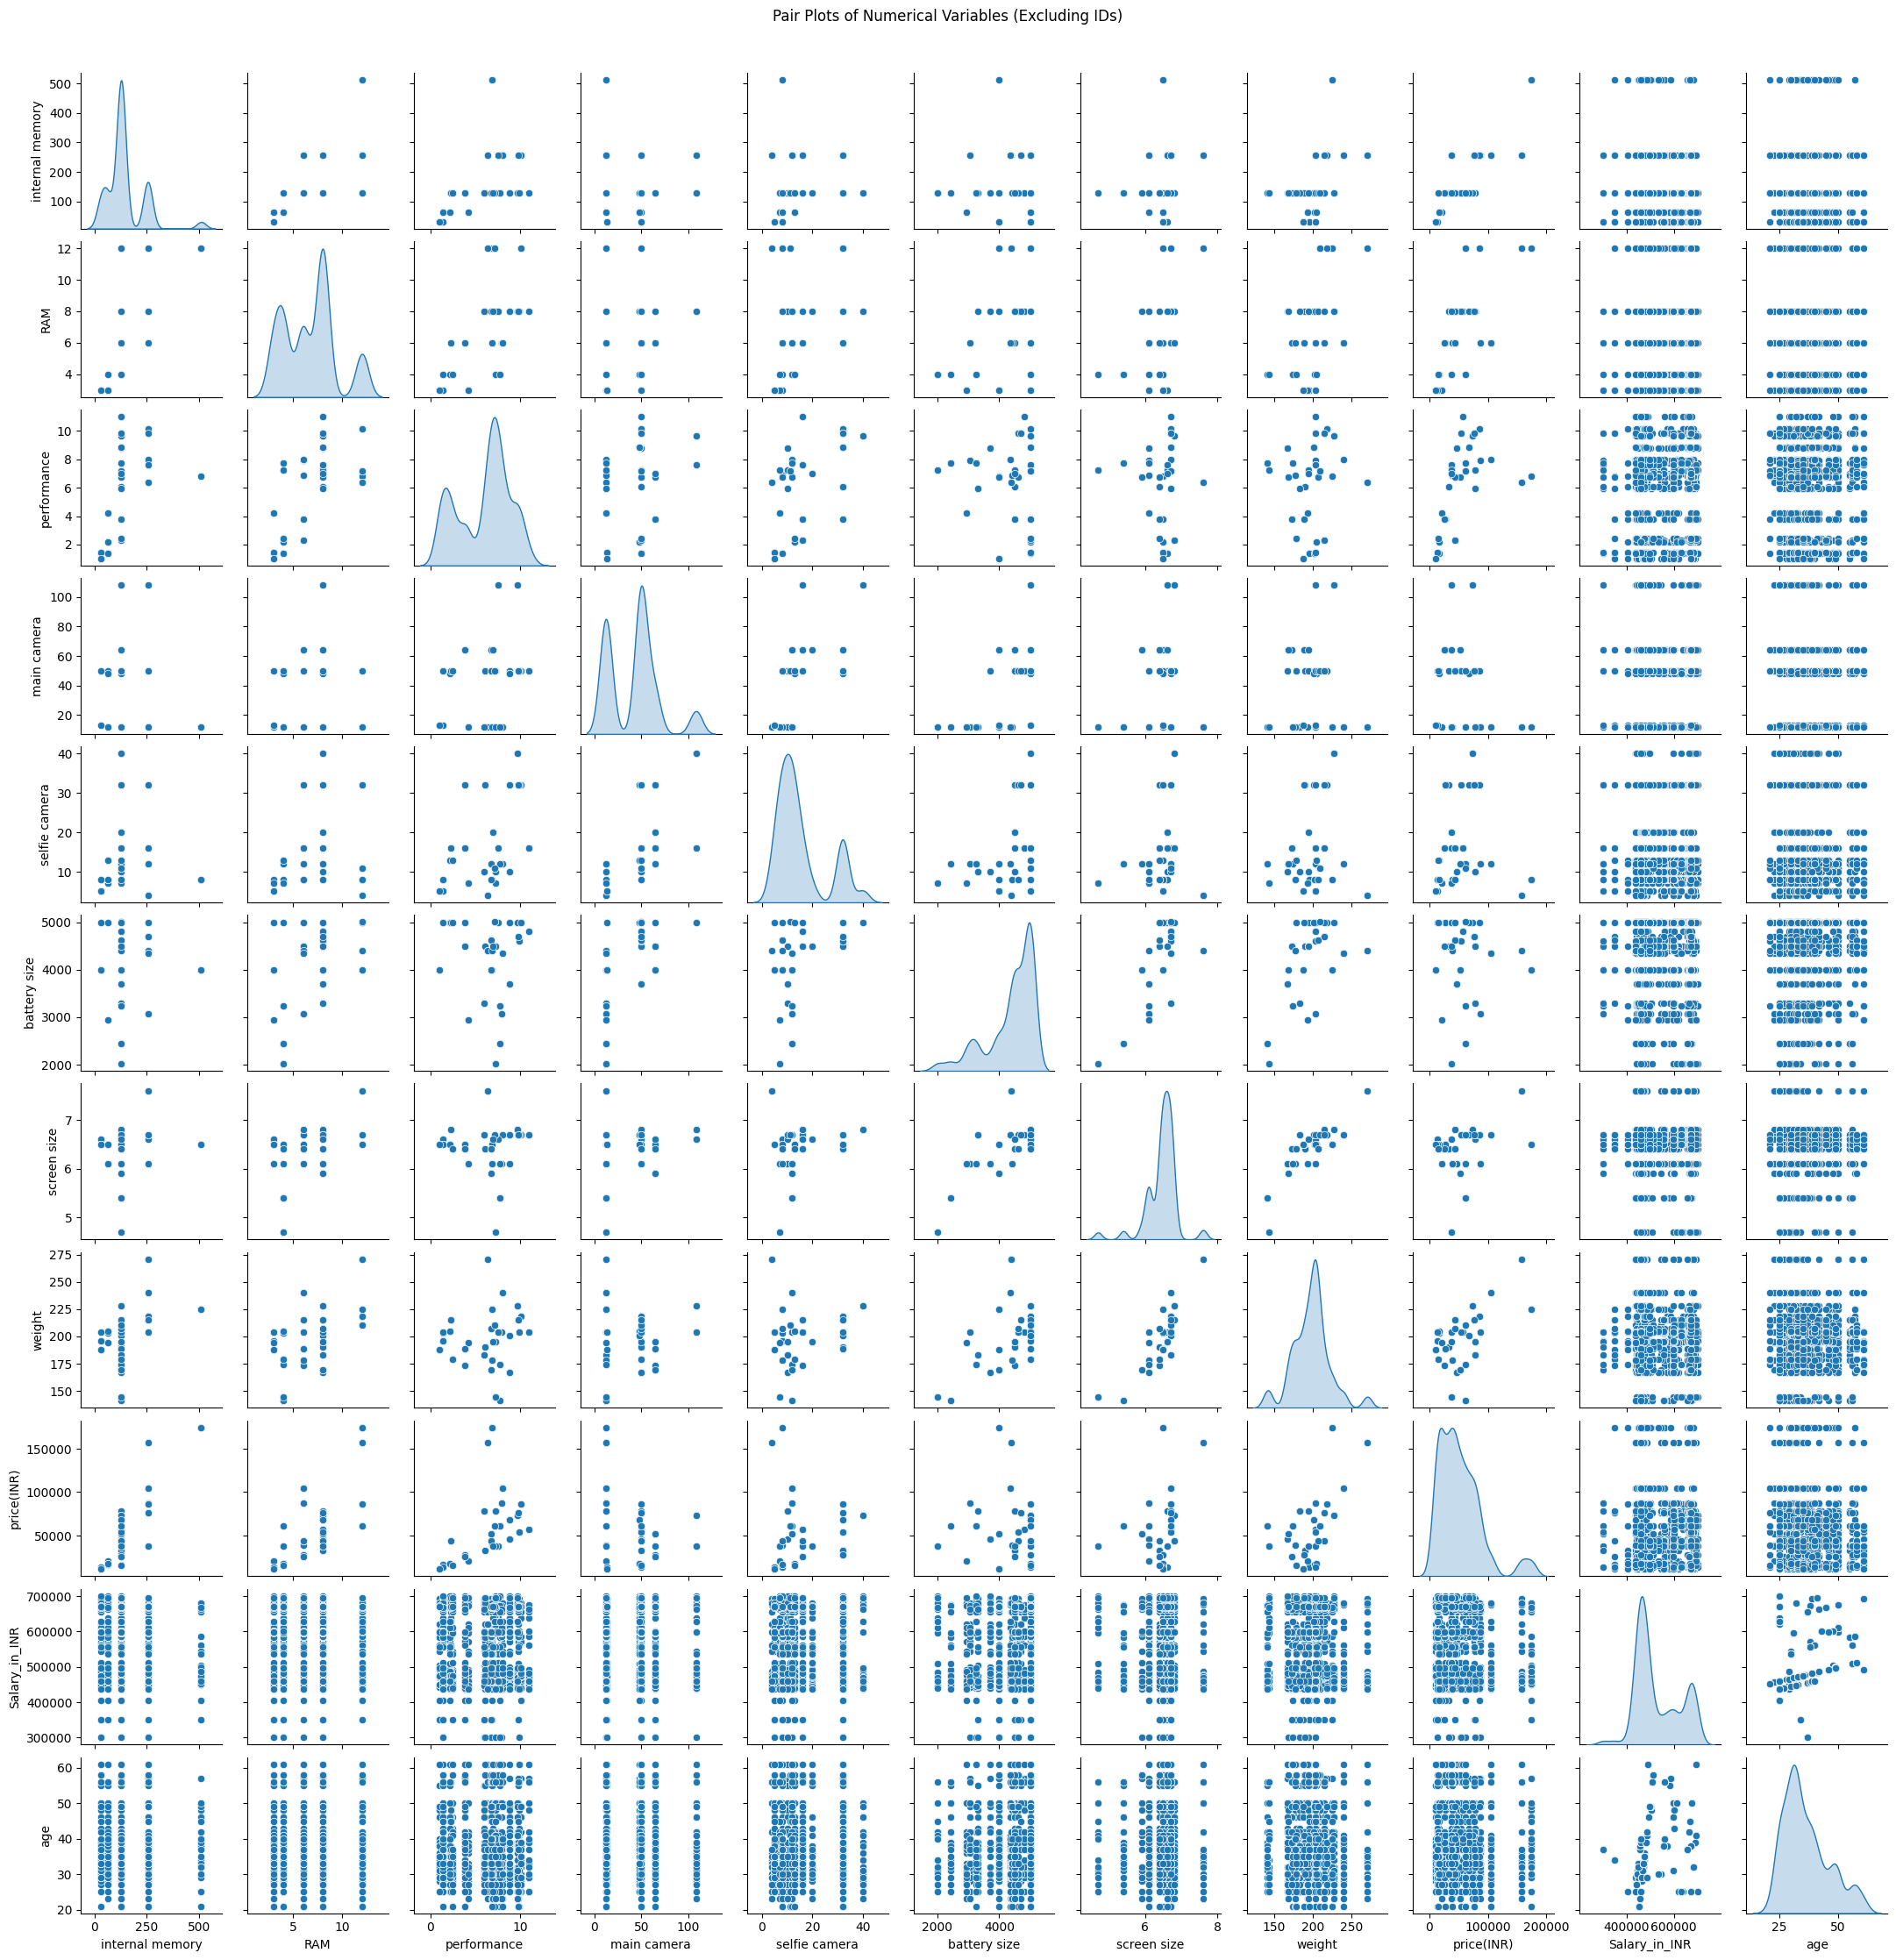

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# numerical_cols_for_boxplot already contains the filtered numerical columns
# ['rating', 'internal memory', 'RAM', 'performance', 'main camera', 'selfie camera',
# 'battery size', 'screen size', 'weight', 'price(INR)', 'Salary_in_INR', 'age']

# Create a Pair Plot for the selected numerical columns
print("Generating Pair Plots for Numerical Variables (Excluding IDs).")

pair_plot = sns.pairplot(df[new_numerical_column], diag_kind='kde', height=2)
pair_plot.fig.suptitle('Pair Plots of Numerical Variables (Excluding IDs)', y=1.02) # Adjust title position
plt.show()

#### For the following all questions, replace the '_' with correct variable name according to question requirement

# 1. Hypothesis Testing

:## 1a. Two-sample t-test: Salary difference between genders

In [ ]:
male_salary = df[df['gender']=='Male']['Salary_in_INR']
female_salary = df[df['gender']=='Female']['Salary_in_INR']
#H0= there is no difference between the salary between genders
#HA= there is  difference between the salary between genders
t_stat, p_value = stats.ttest_ind(male_salary, female_salary)
print("T-test: Salary difference between genders")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Salary difference between genders
t-statistic: -2.247686529084287 p-value: 0.024816102588423032 



The result indicates that , the p-vale is 0.025<0.05, thus the null hypothesis(H0) is rejected and the mean salaries of female is higher than that of male .

\## 1b. One-sample t-test: RAM > 16 GB

In [ ]:
t_stat, p_value = stats.ttest_1samp(df['RAM'], 16, alternative='greater')
#H0= RAM <= 16 GB
#HA= RAM > 16 GB
print("One-sample t-test: Mean RAM > 16 GB")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Mean RAM > 16 GB
t-statistic: -109.71494869112836 p-value: 1.0 



The result indicates that , the p-vale is 1.0>0.05, this strongly indicates that the null hypothesis(H0) is true and the mean value of RAM is not greater than 16 GB

## 1c. One-sample t-test: Main camera > 12 MP


In [ ]:
t_stat, p_value = stats.ttest_1samp(df['main camera'], 12, alternative='greater')
#H0= Main camera <= 12 MP
#HA= Main camera > 12 MP
print("One-sample t-test: Main camera > 12 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Main camera > 12 MP
t-statistic: 35.6415218671936 p-value: 6.466166332868273e-180 



The p-vale is 6.466166332868273e-180 is nearly equal to 0 , thus the p-value < 0.05 , thus we reject H0 and accept that the mean value of Main camera > 12 MP

## 1d. Two-sample t-test: Price difference between Android and iOS

In [ ]:
android_price = df[df['operating system']=='Android']['price(INR)']
ios_price = df[df['operating system']=='iOS']['price(INR)']
t_stat, p_value = stats.ttest_ind(android_price, ios_price)
#H0= there is no difference between the price between operating sytem
#HA= there is  difference between the price between operating sytem
print("T-test: Price difference between Android and iOS")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Price difference between Android and iOS
t-statistic: -4.466996840290052 p-value: 8.848111231308473e-06 



The result indicates that , the p-value is nearly equal to 0 , thus p-value<0.05, thus the null hypothesis(H0) is rejected and the mean price of iOS is higher than that of Andriod .

## 1e. One-sample t-test: Selfie camera > 8 MP

In [ ]:
t_stat, p_value = stats.ttest_1samp(df['selfie camera'], 8, alternative='greater')
#H0 = Selfie camera <= 8 MP
#HA = Selfie camera > 8 MP
print("One-sample t-test: Selfie camera > 8 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Selfie camera > 8 MP
t-statistic: 23.51346761866551 p-value: 9.08337997279999e-98 



The p-vale is 9.08337997279999e-98 is nearly equal to 0 , thus the p-value < 0.05 , thus we reject H0 and accept that the mean value of Selfie camera > 8 MP

## 1f. One-sample t-test: Battery size > 4000 mAh

In [ ]:
t_stat, p_value = stats.ttest_1samp(df['battery size'], 4000, alternative='greater')
#H0 = Battery size <= 4000 mAh
#HA= Battery size > 4000 mAh
print("One-sample t-test: Battery size > 4000 mAh")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Battery size > 4000 mAh
t-statistic: 15.508314925000109 p-value: 5.106907137628001e-49 



The p-vale is 5.106907137628001e-49 is nearly equal to 0 , thus the p-value < 0.05 , thus we reject H0 and accept that the mean value of Battery Size > 4000 mAh

## 1g. Two-sample t-test: Salary difference across regions (Delhi vs Mumbai)

In [ ]:
if 'Delhi' in df['Region(City)'].unique() and 'Mumbai' in df['Region(City)'].unique():
    delhi_salary = df[df['Region(City)']=='Delhi']['Salary_in_INR']
    mumbai_salary = df[df['Region(City)']=='Mumbai']['Salary_in_INR']
    #H0= there is no difference between the salary between regions(Delhi vs Mumbai)
    #HA= there is  difference between the salary between regions(Delhi vs Mumbai)
    t_stat, p_value = stats.ttest_ind(delhi_salary, mumbai_salary)
    print("T-test: Salary difference between Delhi and Mumbai")
    print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Salary difference between Delhi and Mumbai
t-statistic: -3.7216214193802313 p-value: 0.0002429934026022267 



The result indicates that , the p-value is nearly equal to 0 , thus p-value<0.05, thus the null hypothesis(H0) is rejected and the mean salary of Mumbai is higher than that of Delhi .

# 2. ANOVA Tests

## 2a. Price difference across brands

In [ ]:
brands_price = [df[df['brand']==b]['price(INR)'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_price)
#H0= there is no difference between the Price between brands
#HA= there is difference between the Price between brands
print("ANOVA: Price difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Price difference across brands
F-statistic: 105.6938582813186 p-value: 8.400100625599546e-138 



The p-vale is 8.400100625599546e-138 is nearly equal to 0 , thus the p-value < 0.05 , thus we reject H0 and accept that there is significant difference between the Price between brands



## 2b. Price difference across occupations

In [ ]:
occupations_price = [df[df['occupation']==o]['price(INR)'] for o in df['occupation'].unique()]
f_stat, p_value = stats.f_oneway(*occupations_price)
#H0= there is no difference between the Price across occupation
#HA= there is difference between the Price across occupation
print("ANOVA: Price difference across occupations")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Price difference across occupations
F-statistic: 0.8784287384499441 p-value: 0.6994122934463652 



Here the p-vale is nearly .69, thus the p-value > 0.05 , thus we accept H0 and accept that there is no difference between the Price between brands


## 2c. Performance rating across age groups (<30, 30-50, >50)

In [ ]:
group1 = df[df['age']<30]['performance']
group2 = df[(df['age']>=30) & (df['age']<=50)]['performance']
group3 = df[df['age']>50]['performance']
f_stat, p_value = stats.f_oneway(group1, group2, group3)
#H0= there is no difference between the Performance rating across ages
#HA= there is difference between the Performance rating across ages
print("ANOVA: Performance rating across age groups")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Performance rating across age groups
F-statistic: 0.2346328250662231 p-value: 0.7909052803742103 



Here the p-vale is nearly .79, thus the p-value > 0.05 , thus we accept H0 and accept that there is no difference between the Performance rating across ages


## 2d. Battery size across brands

In [ ]:
brands_battery = [df[df['brand']==b]['battery size'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_battery)
#H0= there is no difference between the Battery size across brands
#HA= there is difference between the Battery size across brands
print("ANOVA: Battery size difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Battery size difference across brands
F-statistic: 168.5946057117773 p-value: 3.4464217628758763e-192 



Here the p-vale is nearly 3.4464217628758763e-192 which is equal to 0, thus the p-value< 0.05 , thus we reject H0 and accept that there is significant difference between the Battery size across brands



## 2e. Screen size across operating systems

In [ ]:
os_screen = [df[df['operating system']==os]['screen size'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_screen)
print("ANOVA: Screen size difference across OS")
#H0= there is no difference between the Screen size across operating systems
#HA= there is difference between the Screen size across operating systems
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Screen size difference across OS
F-statistic: 389.8499802629494 p-value: 2.0973660013187365e-73 



Here the p-vale is nearly 2.0973660013187365e-73  which is equal to 0, thus the p-value< 0.05 , thus we reject H0 and accept that there is significant difference between the Screen size across operating systems


:## 2g. RAM across operating systems

In [ ]:
os_ram = [df[df['operating system']==os]['RAM'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_ram)
#H0= there is no difference between RAM across operating systems
#HA= there is difference between RAM across operating systems
print("ANOVA: RAM difference across OS")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: RAM difference across OS
F-statistic: 143.9235786733912 p-value: 4.7164275665302215e-31 



Here the p-vale is nearly 4.7164275665302215e-31  which is equal to 0, thus the p-value< 0.05 , thus we reject H0 and accept that there is significant difference between RAM across operating systems


## 2h. Main camera across brands

In [ ]:
brands_camera = [df[df['brand']==b]['main camera'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_camera)
#H0= there is no difference between Main camera across brands
#HA= there is difference between Main camera across brands
print("ANOVA: Main camera difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Main camera difference across brands
F-statistic: 104.0043901548866 p-value: 3.926038714282027e-136 



Here the p-vale is nearly 3.926038714282027e-136  which is equal to 0, thus the p-value< 0.05 , thus we reject H0 and accept that there is significant difference between Main camera across brands


# 3. Chi-Square Tests

## 3a. OS choice vs gender

In [ ]:
os_gender_table = pd.crosstab(df['operating system'], df['gender'])
chi2, p, dof, expected = stats.chi2_contingency(os_gender_table)
#H0= there is no influence of OS choice based on gender
#HA= there is influence ofOS choice based on gender
print("Chi-square: OS choice vs Gender")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: OS choice vs Gender
Chi2: 0.0008101472995090708 p-value: 0.9772928087087882 



Here the p-vale is nearly 0.97 , thus the p-value> 0.05 , thus we accept the H0 and accept that there is no influence of OS choice based on gender



## 3b. Brand choice vs OS

In [ ]:
brand_os_table = pd.crosstab(df['brand'], df['operating system'])
chi2, p, dof, expected = stats.chi2_contingency(brand_os_table)
#H0= there is no influence of Brand choice based on OS
#HA= there is influence of Brand choice based on OS
print("Chi-square: Brand vs OS")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: Brand vs OS
Chi2: 989.9999999999999 p-value: 2.470476980705389e-207 



Here the p-vale is nearly 2.470476980705389e-207 which is equal to 0, thus the p-value< 0.05 , thus we reject H0 and accept that there is influence of Brand choice based on OS


## 3c. Brand choice vs occupation

In [ ]:
brand_occ_table = pd.crosstab(df['brand'], df['occupation'])
chi2, p, dof, expected = stats.chi2_contingency(brand_occ_table)
#H0= there is no influence of Brand choice based on Occupation
#HA= there is influence of Brand choice based on Occupation
print("Chi-square: Brand vs Occupation")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: Brand vs Occupation
Chi2: 284.84565845452767 p-value: 0.9999987418741012 



Here the p-vale is 0.99, thus the p-value> 0.05 , thus we accept the H0 and accept that there is no influence of Brand choice based on Occupation
